## Kr Run 15676 

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

## Configuration

In [2]:
import re
import glob
from collections import namedtuple

import sys
pypaths= ("/Users/hernando/work/investigacion/NEXT/software/nextana",
         "/Users/hernando/work/investigacion/NEXT/software/hipy",
         "/Users/hernando/work/investigacion/NEXT/software/IC")
for ipypath in pypaths:
       sys.path.insert(0,ipypath)

In [3]:
import numpy             as np
import pandas            as pd
import tables            as tb
from   scipy             import stats
from   scipy             import optimize

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import axes3d

plt.rcParams['image.cmap'] = 'rainbow'

In [4]:
import hipy.utils        as ut
import hipy.pltext       as pltext
import hipy.profile      as prof

import nana.kr.krana    as krana
import nana.kr.krmap    as krtool

#import nana.bclouds.bclouds      as bc
#import hipy.hfit         as hfit
from invisible_cities.io.dst_io import load_dst, load_dsts
#import invisible_cities.io.dst_io as dio

In [6]:
pltext.style()

import warnings
warnings.filterwarnings('ignore')

import time
print(' Last revision ', time.asctime())

 Last revision  Wed Feb  5 15:56:03 2025


## Data

In [11]:
path_data = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/data'
path_mc   = '/Users/hernando/work/investigacion/NEXT/data/NEXT100/MC'

#path_run = '/15675/kdst/ldc1'
#path_run = '/15675/kdst'
path_run = '/Kr/250203_4bar'

from os import listdir

filenames = listdir(path_mc + path_run)
filenames = ['merged.kdst',]
#filenames = ['merged_kdst.h5',]
filenames.sort()
print('number of files :', len(filenames))
print('fist files: ', filenames[0], filenames[-1])
filenames = [path_mc + path_run + '/' + ifile for ifile in filenames]

number of files : 1
fist files:  merged.kdst merged.kdst


In [13]:
print(filenames)
#kdst = pd.read_hdf(filenames[0])
kdst = load_dst(filenames[0], "DST", "Events")

['/Users/hernando/work/investigacion/NEXT/data/NEXT100/MC/Kr/250203_4bar/merged.kdst']


## Fidutial selection

In [14]:
print('size x ', np.min(kdst.X[kdst.X > -1000.]), np.max(kdst.X))
print('size y ', np.min(kdst.Y[kdst.Y > -1000.]), np.max(kdst.Y))
kdst = kdst.rename(columns = {'S2e' : 'energy', 'X' : 'x', 'Y' : 'y', 'Z' : 'z', 
                              'DT' : 'dtime', 'R' : 'r'})
print(list(kdst.columns))

size x  -482.625 490.02500000000003
size y  -479.9250000000001 492.7250000000001
['event', 'time', 's1_peak', 's2_peak', 'nS1', 'nS2', 'S1w', 'S1h', 'S1e', 'S1t', 'S2w', 'S2h', 'energy', 'S2q', 'S2t', 'qmax', 'Nsipm', 'dtime', 'z', 'Zrms', 'x', 'y', 'r', 'Phi', 'Xrms', 'Yrms']


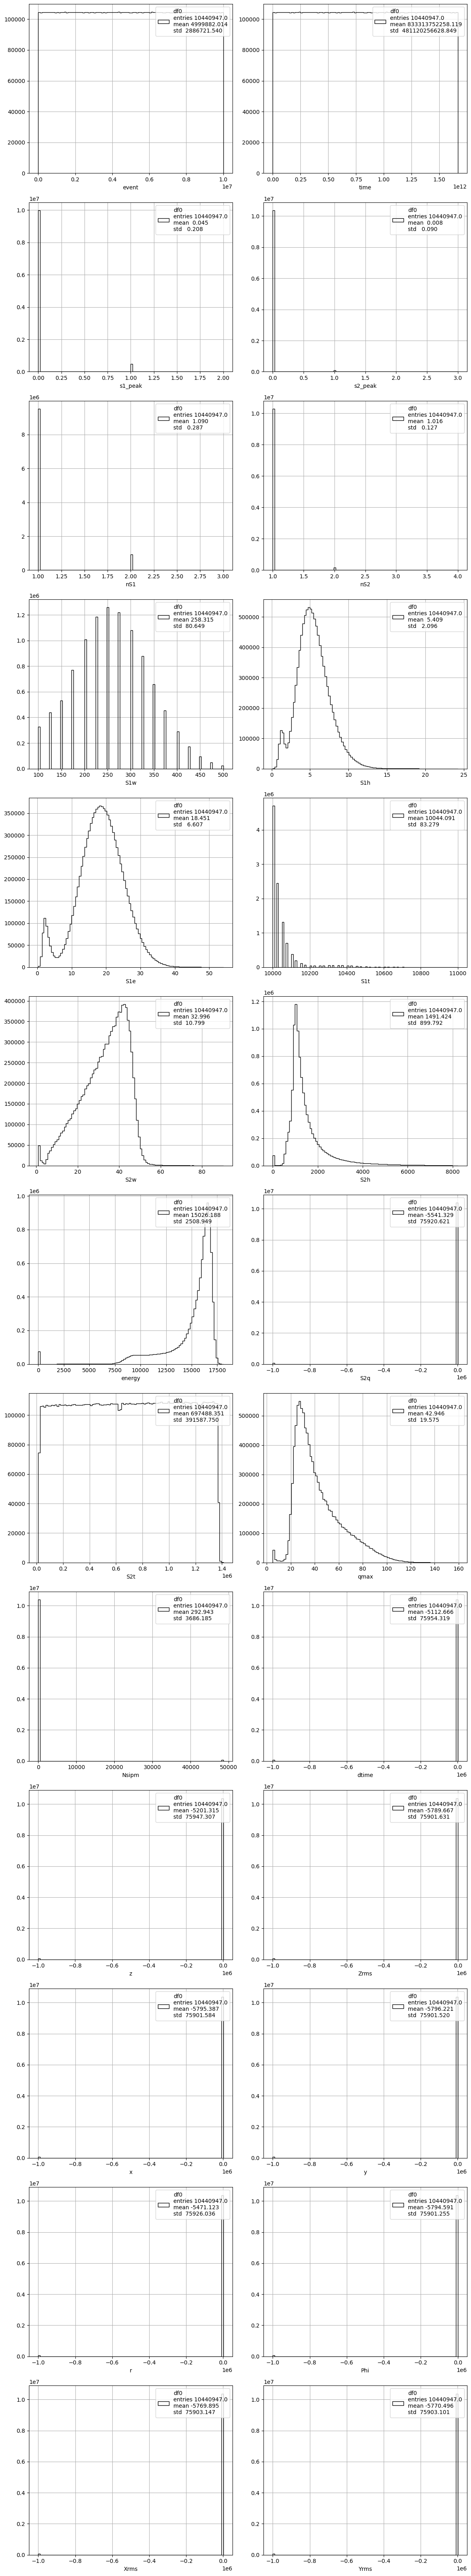

In [15]:
pltext.df_inspect(kdst)

In [23]:
sels = {}
sels['r']        = ut.in_range(kdst.r  , (0., 500.))
sels['dtime']    = ut.in_range(kdst.dtime , (0., 2000.))
sels['energy']   = ut.in_range(kdst.energy, (7e3, 20e3))
sels['1S2']      = kdst.nS2 == 1
sels['fidutial'] = (sels['r']) & (sels['dtime']) & (sels['energy']) & (sels['1S2'])

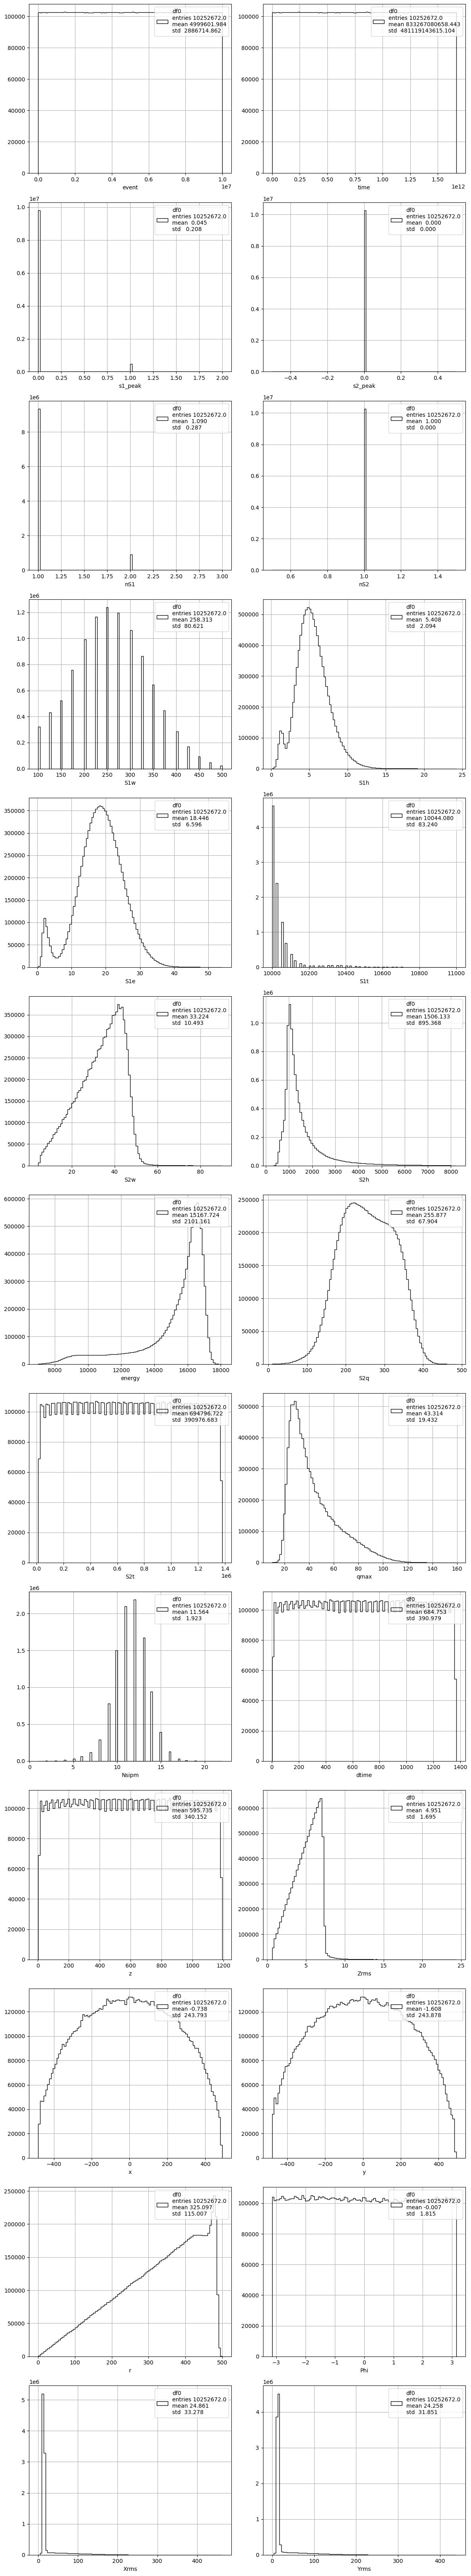

In [24]:
sel = sels['fidutial']
pltext.df_inspect(kdst[sel])

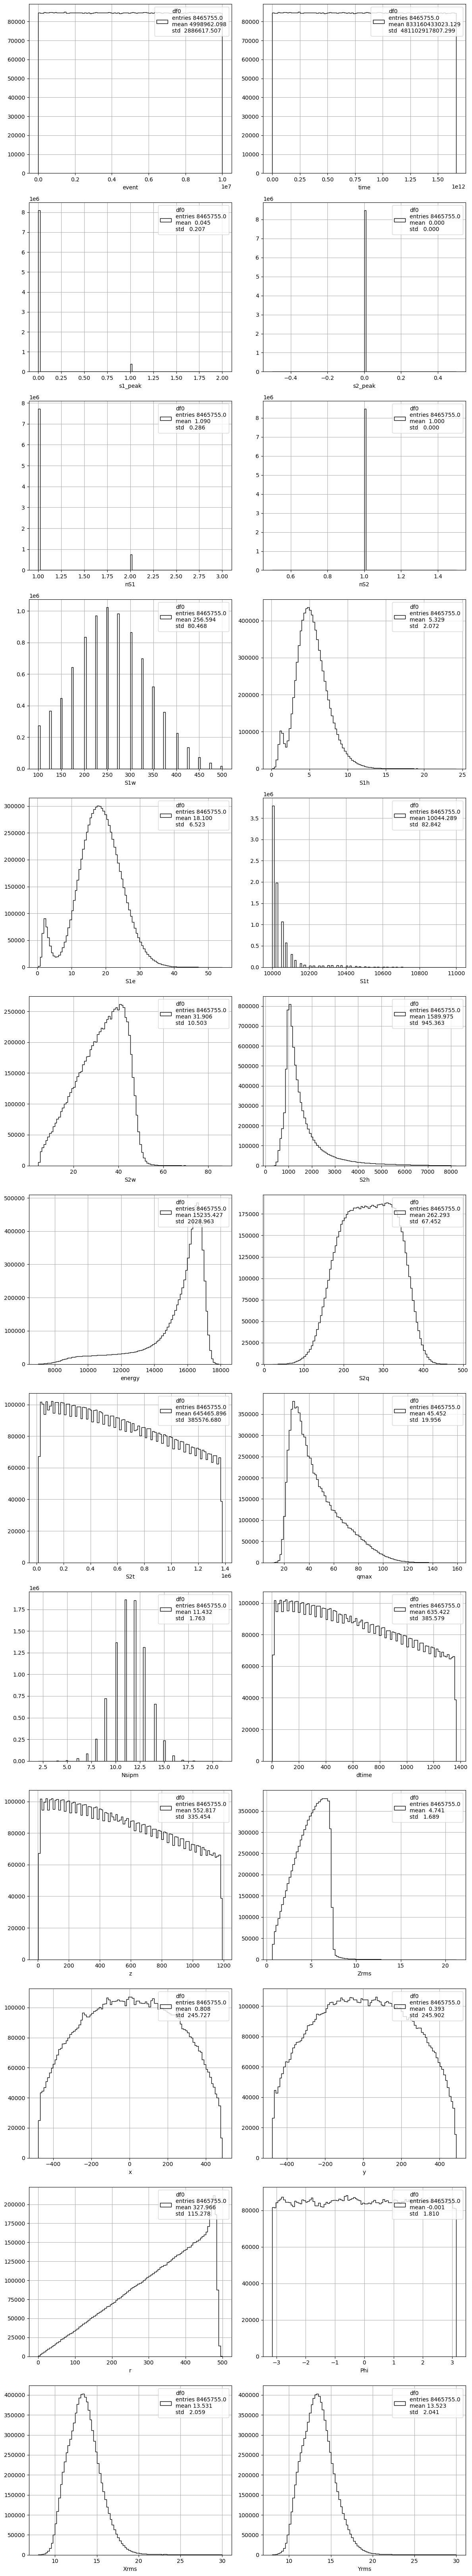

In [25]:
sels['XYrms'] = (ut.in_range(kdst.Xrms, (8, 30))) & (ut.in_range(kdst.Yrms, (8, 30)))
sel           = (sels['fidutial']) & (sels['XYrms'])
pltext.df_inspect(kdst[sel])

## S2

In [14]:
## good s1 by Gonzeo
#sels['S2w'] = kdst.S2w < 40
#sels['S2t'] = ut.in_range(kdst[sel].S2t*(25e-6), (38, 42.))
#sels['S2e'] = ut.in_range(kdst.energy, (2000., 8000.))
#sels['S2'] = (sels['1S2']) & (sels['S2w']) & (sels['S2e']) & (sels['S2t'])

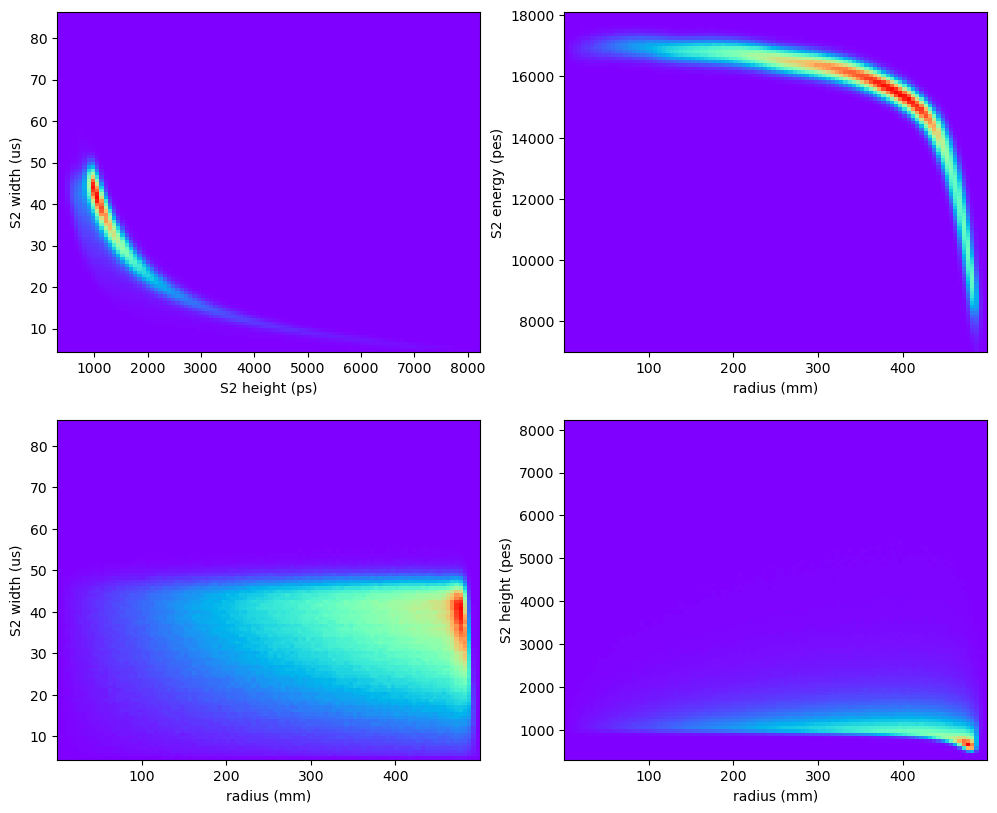

In [26]:
sel = (sels['XYrms']) & (sels['fidutial'])

canvas = pltext.canvas(6, 2)
canvas(1)
plt.hist2d(kdst[sel].S2h, kdst[sel].S2w, 100);
plt.xlabel('S2 height (ps)'); plt.ylabel('S2 width (us)')

canvas(2)
plt.hist2d(kdst[sel].r, kdst[sel].energy, 100);
plt.xlabel('radius (mm)'); plt.ylabel('S2 energy (pes)');

canvas(3)
plt.hist2d(kdst[sel].r, kdst[sel].S2w, 100);
plt.xlabel('radius (mm)'); plt.ylabel('S2 width (us)');

canvas(4)
plt.hist2d(kdst[sel].r, kdst[sel].S2h, 100);
plt.xlabel('radius (mm)'); plt.ylabel('S2 height (pes)');


## S1

In [27]:
gline = lambda w, a, b: ((w-a)/b)**2
gdown = lambda w: gline(w, 5, 1.)
gup   = lambda w: gline(w, 2, 0.75)
sels['S1window'] = ut.in_range(kdst.dtime, (gdown(kdst.S2w), gup(kdst.S2w)))
#sels['dtime']    = kdst.dtime < 1150.


In [28]:
def recompute_npeaks(df):
    events= df.groupby('event')
    ns1= events.s1_peak.nunique().values
    ns2= events.s2_peak.nunique().values
    n = events.s1_peak.count ().values
    df.loc[:, 'nS1'] = np.repeat(ns1,n) 
    df.loc[:, 'nS2'] = np.repeat(ns2,n)
    return df

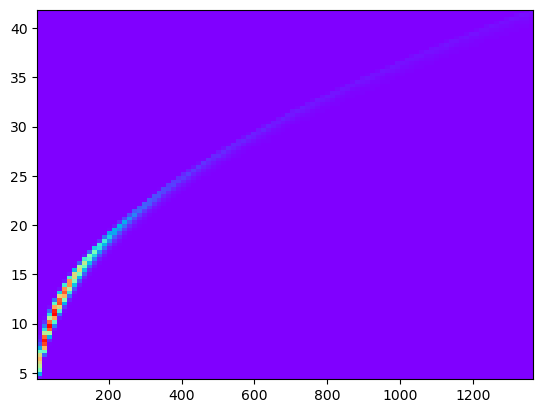

In [29]:
#sel = (sels['fidutial']) & (sels['S1window']) & (sels['dtime'])
sel = (sels['fidutial']) & (sels['XYrms']) & (sels['S1window'])
plt.hist2d(kdst[sel].dtime, kdst[sel].S2w, 100);

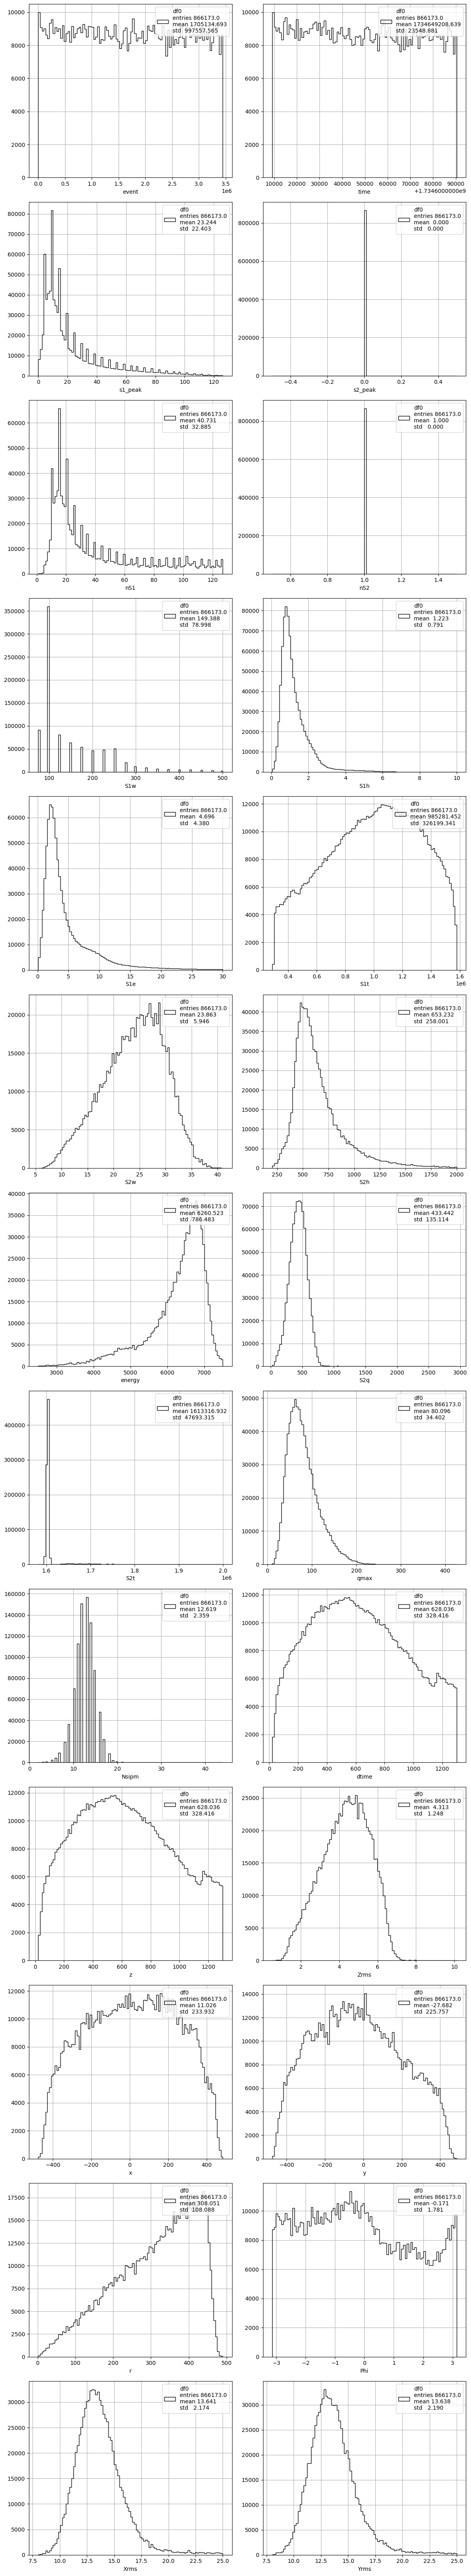

In [113]:
sels['dtime_tight'] = ut.in_range(kdst.dtime, (0, 1300));
sel     = (sels['fidutial']) & (sels['XYrms']) & (sels['S1window']) & (sels['dtime_tight'])
sel_out = (sels['fidutial']) & (sels['XYrms']) & (~sels['S1window']) & (sels['dtime_tight'])

pltext.df_inspect(kdst[sel])

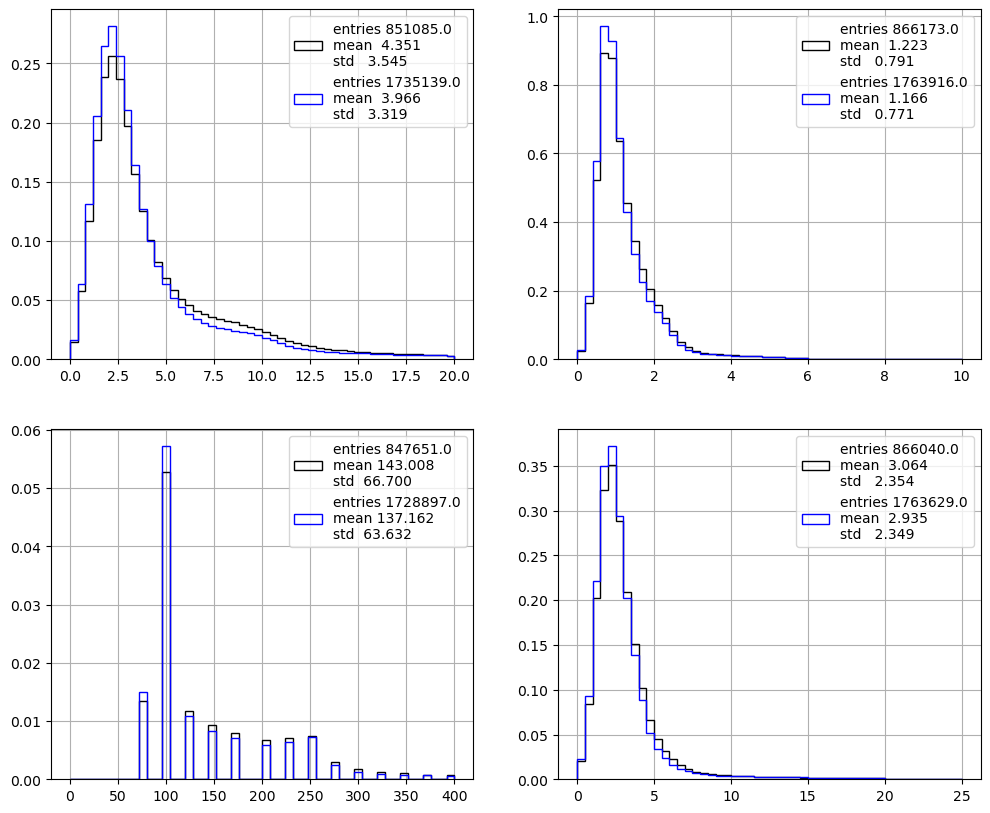

In [114]:
canvas = pltext.canvas(4, 2);
canvas(1)
pltext.hist(kdst[sel]    .S1e, range = (0, 20), bins = 50, density = True)
pltext.hist(kdst[sel_out].S1e, range = (0, 20), bins = 50, density = True);
canvas(2)
pltext.hist(kdst[sel]    .S1h, range = (0, 10), bins = 50, density = True)
pltext.hist(kdst[sel_out].S1h, range = (0, 10), bins = 50, density = True);
canvas(3)
pltext.hist(kdst[sel]    .S1w, range = (0, 400), bins = 50, density = True)
pltext.hist(kdst[sel_out].S1w, range = (0, 400), bins = 50, density = True);
canvas(4)
pltext.hist(100*kdst[sel].S1e/kdst[sel].S1w,         range = (0, 25.), bins = 50, density = True);
pltext.hist(100*kdst[sel_out].S1e/kdst[sel_out].S1w, range = (0, 25.), bins = 50, density = True);




## S1 selection

In [115]:
mkdst = kdst[sel]
mkdst = recompute_npeaks(mkdst)

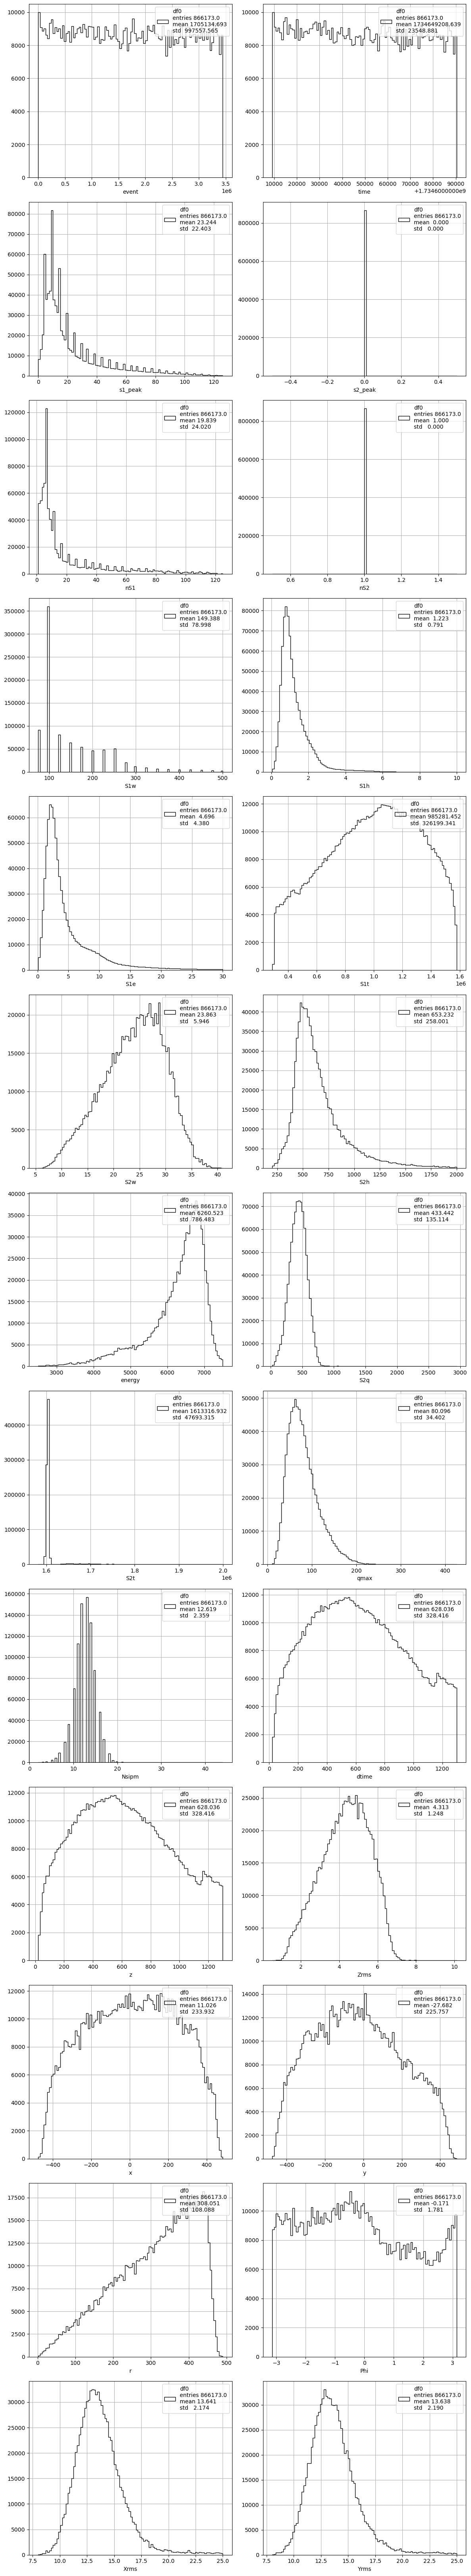

In [116]:
pltext.df_inspect(mkdst)

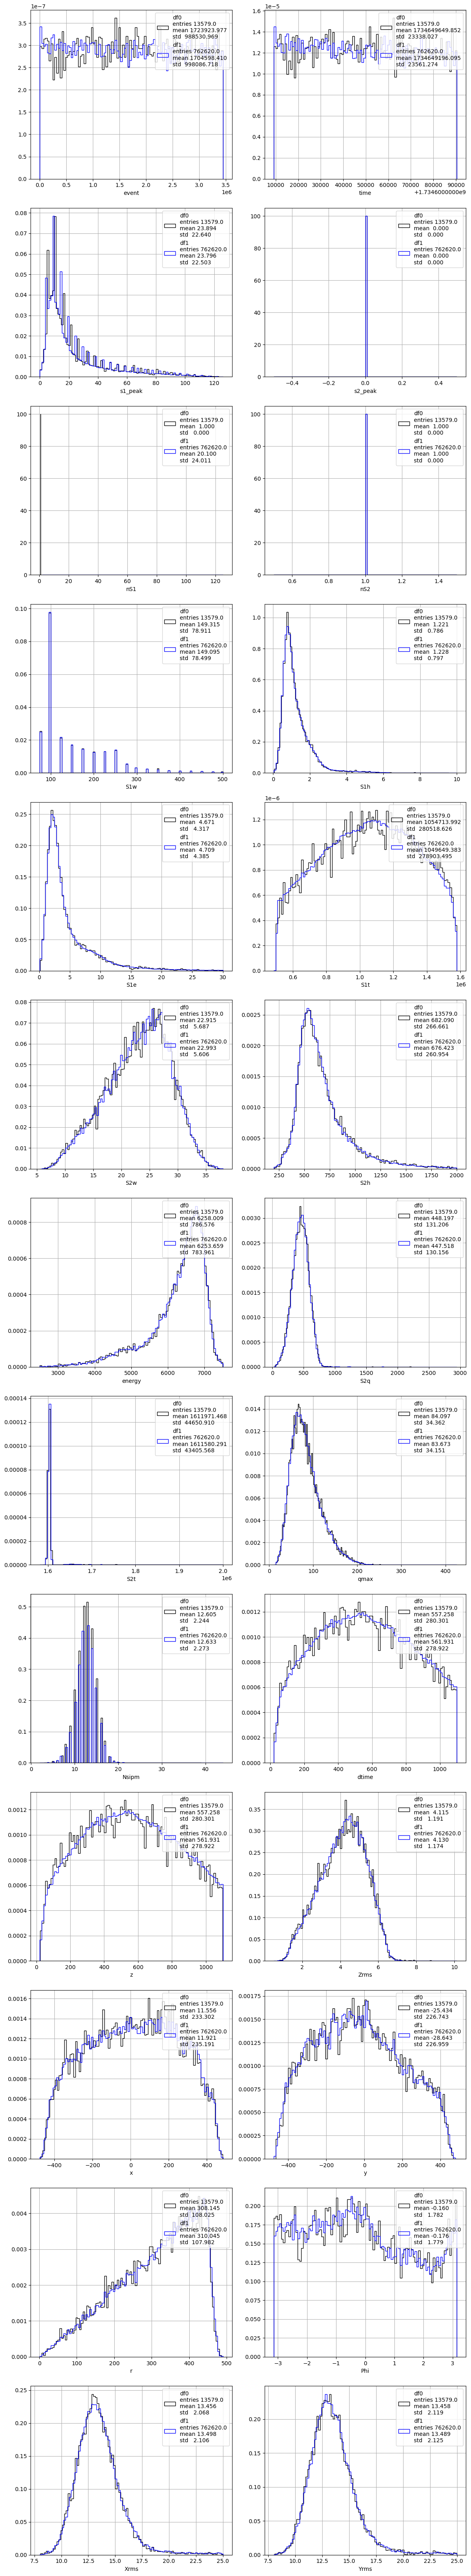

In [224]:
wsels = {}
wsels['dtime_tight'] = mkdst.dtime < 1100.
wsels['1S1'] = mkdst.nS1 == 1
wsels['nS1'] = mkdst.nS1 >= 2
pltext.df_inspect((mkdst[wsels['1S1'] & wsels['dtime_tight']],mkdst[wsels['nS1'] & wsels['dtime_tight']]), density = True)

In [225]:
wsel = wsels['1S1'] & wsels['dtime_tight']

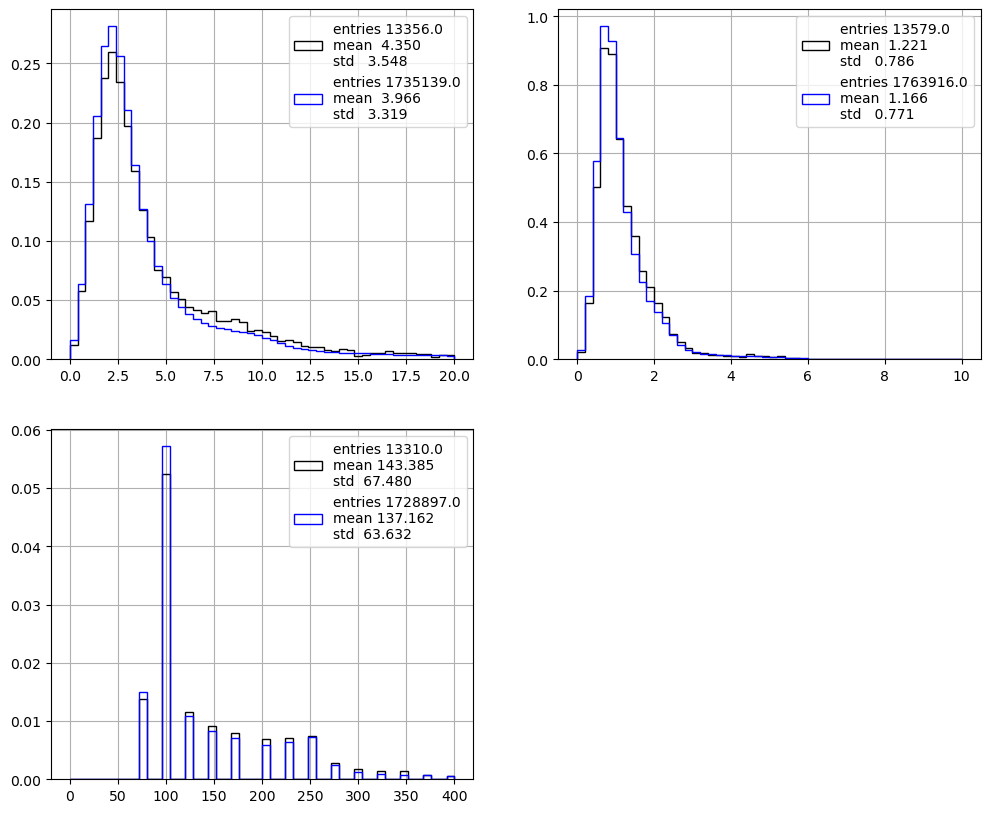

In [226]:
canvas = pltext.canvas(4, 2);
canvas(1)
pltext.hist(mkdst[wsel]  .S1e, range = (0, 20), bins = 50, density = True)
pltext.hist(kdst[sel_out].S1e, range = (0, 20), bins = 50, density = True);
canvas(2)
pltext.hist(mkdst[wsel]  .S1h, range = (0, 10), bins = 50, density = True)
pltext.hist(kdst[sel_out].S1h, range = (0, 10), bins = 50, density = True);
canvas(3)
pltext.hist(mkdst[wsel]  .S1w, range = (0, 400), bins = 50, density = True)
pltext.hist(kdst[sel_out].S1w, range = (0, 400), bins = 50, density = True);

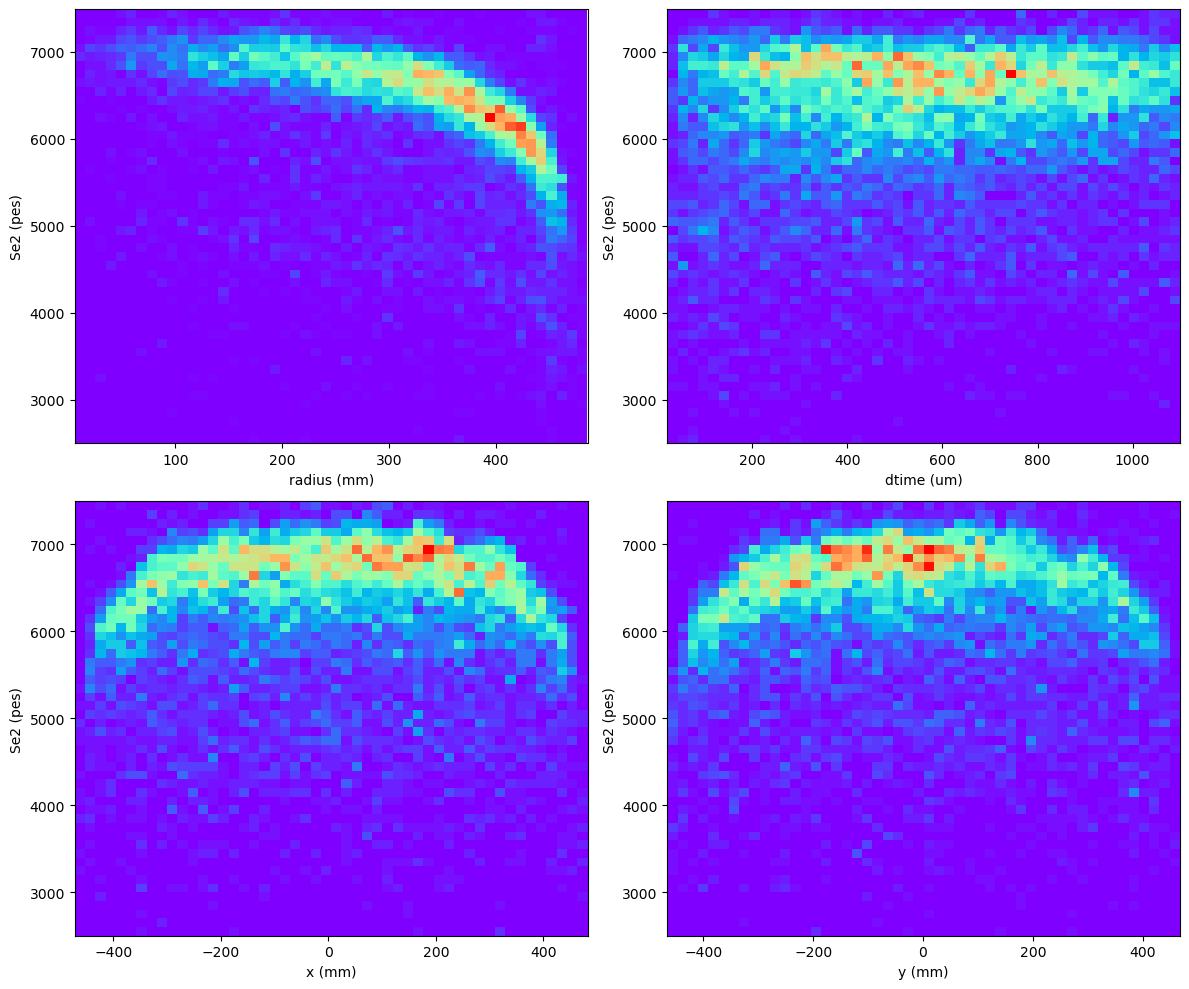

In [227]:
wsel = wsels['1S1'] & wsels['dtime_tight']
bins = (50, 50)
canvas = pltext.canvas(4, 2)
canvas(1)
plt.hist2d(mkdst[wsel].r, mkdst[wsel].energy, bins);
plt.xlabel('radius (mm)'); plt.ylabel('Se2 (pes)');
canvas(2)
plt.hist2d(mkdst[wsel].dtime, mkdst[wsel].energy, bins);
plt.xlabel('dtime (um)'); plt.ylabel('Se2 (pes)');
canvas(3)
plt.hist2d(mkdst[wsel].x, mkdst[wsel].energy, bins);
plt.xlabel('x (mm)'); plt.ylabel('Se2 (pes)');
canvas(4)
plt.hist2d(mkdst[wsel].y, mkdst[wsel].energy, bins);
plt.xlabel('y (mm)'); plt.ylabel('Se2 (pes)');
plt.tight_layout();


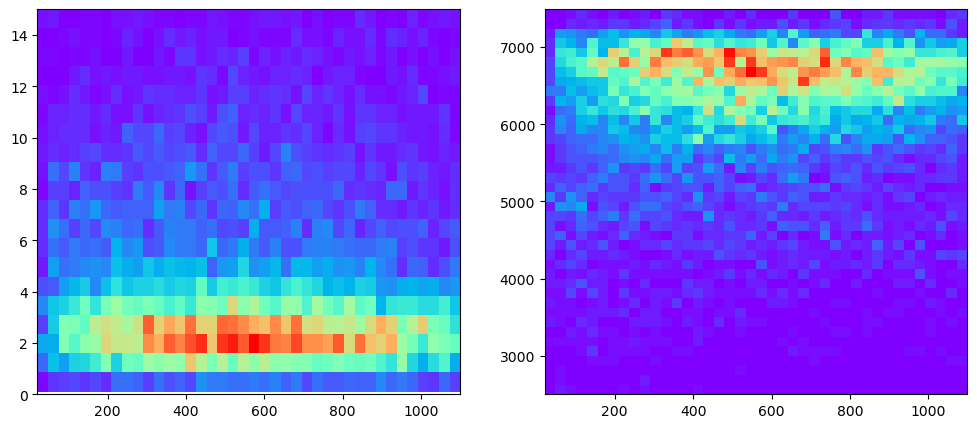

In [228]:
canvas = pltext.canvas(2, 2)
canvas(1)
plt.hist2d(mkdst.dtime[wsel], mkdst.S1e[wsel], 40); plt.ylim(0, 15);
canvas(2)
plt.hist2d(mkdst.dtime[wsel], mkdst.energy[wsel], 40);

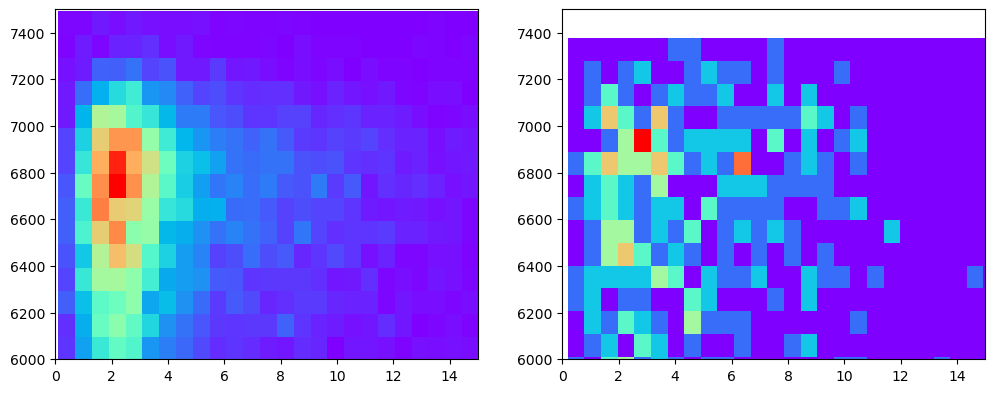

In [229]:
wsels['anode'] = mkdst.dtime < 150

canvas = pltext.canvas(4, 2)
canvas(1)
wsel = wsel
plt.hist2d(mkdst[wsel].S1e, mkdst[wsel].energy, bins); plt.ylim((6000., 7500.)); plt.xlim((0, 15));
canvas(2)
wsels['anode'] = mkdst.dtime < 100
wsel_p = wsel & (wsels['anode'])
plt.hist2d(mkdst[wsel_p].S1e, mkdst[wsel_p].energy, bins); plt.ylim((6000., 7500.)); plt.xlim((0, 15));

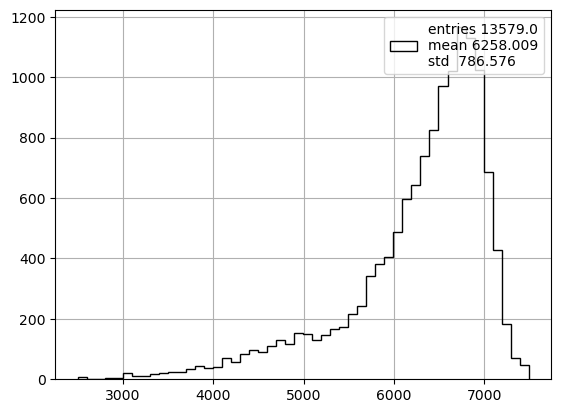

In [230]:
pltext.hist(mkdst.energy[wsel], 50);

In [231]:
wsels['r_tight'] = ut.in_range(mkdst.r, (0, 300))
wsels['anode'] = mkdst.dtime < 100
wsels['xray']    = ut.in_range(mkdst.energy, (4000, 5500))
wsels['kr']      = ut.in_range(mkdst.energy, (5500, 7500))

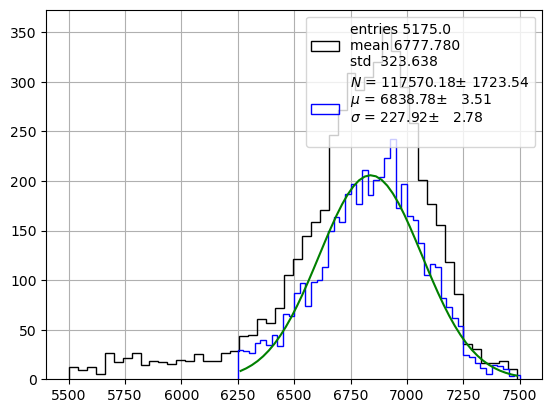

In [232]:
wsel_p = wsel & (wsels['kr']) & (wsels['r_tight'])
pltext.hist(mkdst.energy[wsel_p], 50);
pltext.hfit(mkdst.energy[wsel_p], 50, range= (6250., 7500), fun = 'gaus');

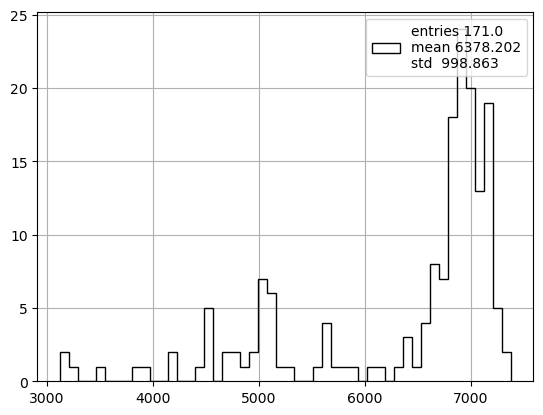

In [233]:
wsel = (wsels['1S1']) & (wsels['r_tight']) & (wsels['anode'])
pltext.hist(mkdst.energy[wsel], 50);

resolution FWHM  6.4 %


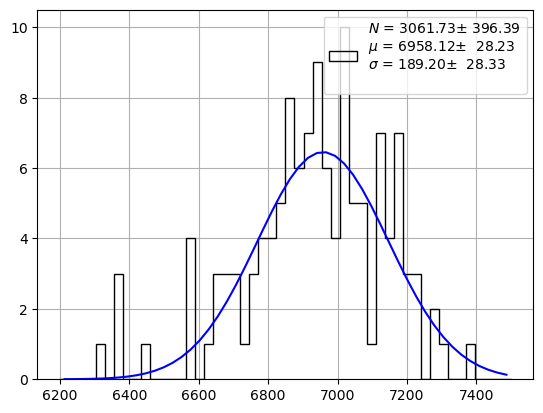

In [234]:
wsel = wsel & (mkdst.energy > 5500) & (mkdst.dtime < 1000.)
#pltext.hist(mkdst[wsel].energy, 50, (6500, 7500));
pltext.hfit(mkdst[wsel].energy, 50, range = (6200, 7500), fun = 'gaus');
print('resolution FWHM {:4.2} %'.format(189.1/6946*235.))

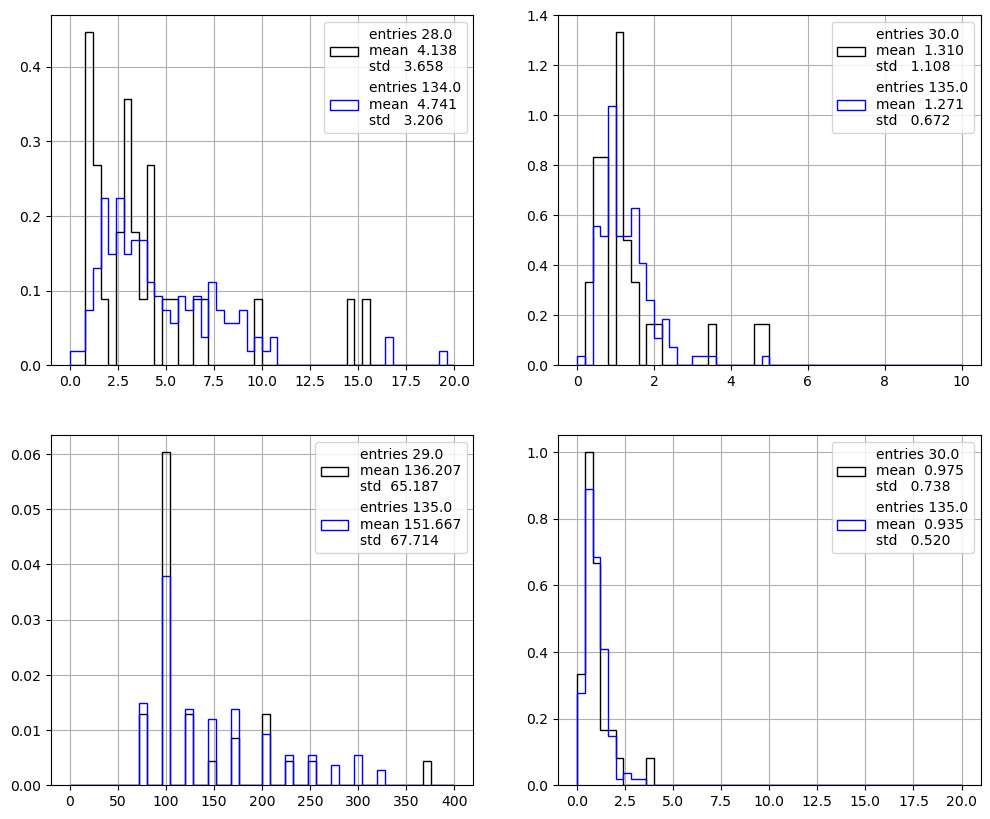

In [198]:
wsel_xray = wsel & (wsels['xray'])
wsel_kr   = wsel & (wsels['kr'])
canvas = pltext.canvas(4, 2)
canvas(1)
pltext.hist(mkdst[wsel_xray].S1e, range = (0, 20), bins = 50, density = True);
pltext.hist(mkdst[wsel_kr]  .S1e, range = (0, 20), bins = 50, density = True);
canvas(2)
pltext.hist(mkdst[wsel_xray].S1h, range = (0, 10), bins = 50, density = True);
pltext.hist(mkdst[wsel_kr]  .S1h, range = (0, 10), bins = 50, density = True);
canvas(3)
pltext.hist(mkdst[wsel_xray].S1w, range = (0, 400), bins = 50, density = True);
pltext.hist(mkdst[wsel_kr]  .S1w, range = (0, 400), bins = 50, density = True);
canvas(4)
pltext.hist(100*mkdst[wsel_xray].S1h/mkdst[wsel_xray].S1w, range = (0, 20), bins = 50, density = True);
pltext.hist(100*mkdst[wsel_kr]  .S1h/mkdst[wsel_kr].S1w  , range = (0, 20), bins = 50, density = True);

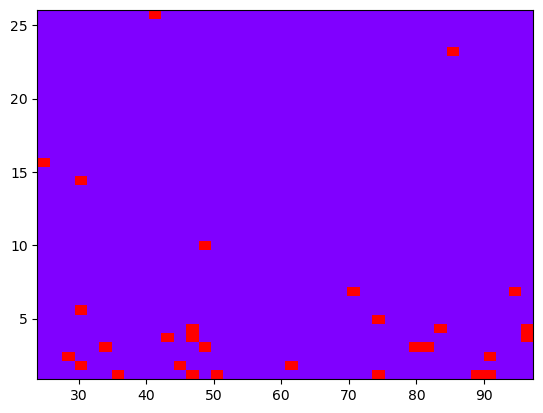

In [199]:
plt.hist2d(mkdst[wsel_xray].dtime, mkdst[wsel_xray].S1e, bins = 40);

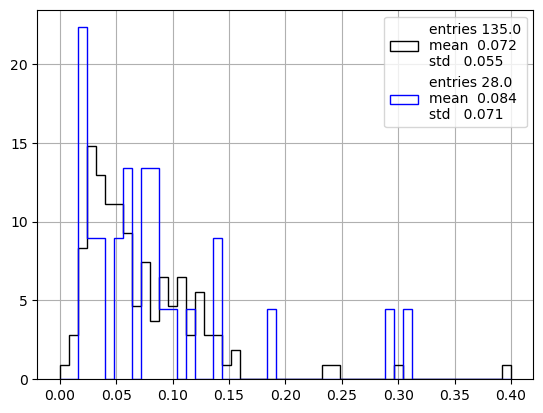

In [200]:
pltext.hist(100.*mkdst[wsel_kr].S1e/mkdst[wsel_kr].energy, range = (0, 0.4), bins = 50, density = True);
pltext.hist(100.*mkdst[wsel_xray].S1e/mkdst[wsel_xray].energy, range = (0, 0.4), bins = 50, density = True);

In [111]:
3.5 * np.sqrt(16./7.)

5.2915026221291805

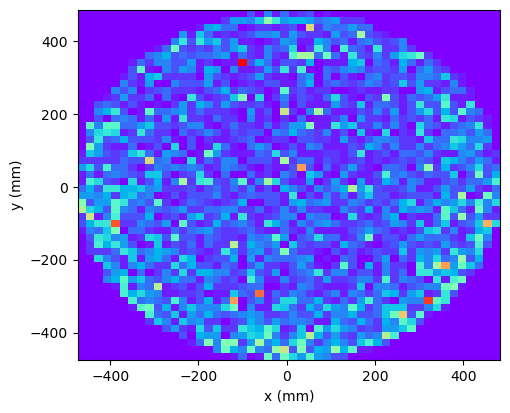

In [63]:
wsel = wsels['1S1']
bins = (50, 50)
canvas = pltext.canvas(4, 2)
canvas(1)
plt.hist2d(mkdst[wsel].x, mkdst[wsel].y, bins);
plt.xlabel('x (mm)'); plt.ylabel('y (mm)');
# canvas(2)
# plt.hist2d(mkdst[wsel].dtime, mkdst[wsel].energy, bins);
# plt.xlabel('dtime (um)'); plt.ylabel('Se2 (pes)');
# canvas(3)
# plt.hist2d(mkdst[wsel].x, mkdst[wsel].energy, bins);
# plt.xlabel('x (mm)'); plt.ylabel('Se2 (pes)');
# canvas(4)
# plt.hist2d(mkdst[wsel].y, mkdst[wsel].energy, bins);
# plt.xlabel('y (mm)'); plt.ylabel('Se2 (pes)');
# plt.tight_layout();


In [254]:
L = 4.
B = 1.
P = 150.
R = (P/(0.3*B))
print(R)
stheta = L/R
print('radius ', R)
print('stheta ', stheta)
ctheta = np.sqrt(1 - stheta**2)
print('ctheta ', ctheta)
d = R * (1 - ctheta)
print('distance ', d)
print('sigma ', 2*d/5.)

500.0
radius  500.0
stheta  0.008
ctheta  0.9999679994879836
distance  0.016000256008175118
sigma  0.006400102403270047


In [270]:
barn     = 1e-24
sigma_pp = 60e-3 # cm2
lumi     = 1e34 # /(cm2 s)
sigma_h  = 54e-12 # cm2 
w        = 40e6 # Hz
nu_pp    = sigma_pp * lumi * barn
n_pp      = nu_pp/w
br        = 0.2e-2
time      = 1.e7
nu_hgg    = lumi * sigma_h * br * barn
epsilon   = 0.8
nu_exp_hgg = nu_hgg * (epsilon**2)
print('nu pp ', nu_pp/1e6)
print('n pp', n_pp)
print('nu_hgg', nu_hgg)
print('n hgg year ', nu_hgg * time)
print('nu hgg obs ', nu_hgg * time * epsilon**2)
print(np.sqrt(nu_hgg * time * epsilon**2))
6912-80

nu pp  599.9999999999999
n pp 14.999999999999996
nu_hgg 0.00108
n hgg year  10800.0
nu hgg obs  6912.000000000001
83.13843876330611


6832

In [272]:
M  = 6938
ss = M/(epsilon**2 * time * br * lumi * barn)
print(ss/1e-12)

54.203125


In [3]:
0.0838/2.

0.0419

In [ ]:
54*1e-12*lumi*